##1. Import Required Libraries

In [2]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    mannwhitneyu,
    chi2_contingency,
    rankdata
)

from statsmodels.stats.multitest import multipletests


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.5f}"
)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

print("Statistical analysis environment initialized.")

Statistical analysis environment initialized.


In [3]:
DATA_PATH = "../data/processed/transactions_behavioral.csv"

RESULT_DIR = "../results/statistical_analysis"
FIGURE_DIR = f"{RESULT_DIR}/figures"

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

print("Data path:", DATA_PATH)
print("Result directory:", RESULT_DIR)
print("Figure directory:", FIGURE_DIR)

Data path: ../data/processed/transactions_behavioral.csv
Result directory: ../results/statistical_analysis
Figure directory: ../results/statistical_analysis/figures


In [4]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (283726, 39)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour,Time_Period,Amount_Log,Amount_Category,Transaction_Time,Transactions_Last_1H,Transactions_Last_24H,Amount_ZScore
0,0.00000,-1.35981,-0.07278,2.53635,1.37816,-0.33832,0.46239,0.23960,0.09870,0.36379,0.09079,-0.55160,-0.61780,-0.99139,-0.31117,1.46818,-0.47040,0.20797,0.02579,0.40399,0.25141,-0.01831,0.27784,-0.11047,0.06693,0.12854,-0.18911,0.13356,-0.02105,149.62000,0,0,Night,5.01476,Medium,0 days 00:00:00,0.00000,0.00000,0.24420
1,0.00000,1.19186,0.26615,0.16648,0.44815,0.06002,-0.08236,-0.07880,0.08510,-0.25543,-0.16697,1.61273,1.06524,0.48910,-0.14377,0.63556,0.46392,-0.11480,-0.18336,-0.14578,-0.06908,-0.22578,-0.63867,0.10129,-0.33985,0.16717,0.12589,-0.00898,0.01472,2.69000,0,0,Night,1.30563,Low,0 days 00:00:00,0.00000,0.00000,-0.34258
2,1.00000,-1.35835,-1.34016,1.77321,0.37978,-0.50320,1.80050,0.79146,0.24768,-1.51465,0.20764,0.62450,0.06608,0.71729,-0.16595,2.34586,-2.89008,1.10997,-0.12136,-2.26186,0.52498,0.24800,0.77168,0.90941,-0.68928,-0.32764,-0.13910,-0.05535,-0.05975,378.66000,0,0,Night,5.93928,High,0 days 00:00:01,2.00000,2.00000,1.15890
3,1.00000,-0.96627,-0.18523,1.79299,-0.86329,-0.01031,1.24720,0.23761,0.37744,-1.38702,-0.05495,-0.22649,0.17823,0.50776,-0.28792,-0.63142,-1.05965,-0.68409,1.96578,-1.23262,-0.20804,-0.10830,0.00527,-0.19032,-1.17558,0.64738,-0.22193,0.06272,0.06146,123.50000,0,0,Night,4.82431,Medium,0 days 00:00:01,2.00000,2.00000,0.13989
4,2.00000,-1.15823,0.87774,1.54872,0.40303,-0.40719,0.09592,0.59294,-0.27053,0.81774,0.75307,-0.82284,0.53820,1.34585,-1.11967,0.17512,-0.45145,-0.23703,-0.03819,0.80349,0.40854,-0.00943,0.79828,-0.13746,0.14127,-0.20601,0.50229,0.21942,0.21515,69.99000,0,0,Night,4.26254,Medium,0 days 00:00:02,4.00000,4.00000,-0.07381


##2. Basic Statistical Overview

First, let's get a basic statistical overview of the dataset. We will look at the summary statistics for numerical columns and the distribution of categorical variables.

In [6]:
print("\nShape:")
print(df.shape)

print("\nMissing values:")
missing_values = df.isnull().sum()

display(
    missing_values[
        missing_values > 0
    ].to_frame("Missing_Count")
)

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget distribution:")
display(
    df["Class"]
    .value_counts()
    .to_frame("Count")
)

print("\nTarget distribution (%):")
display(
    (
        df["Class"]
        .value_counts(normalize=True)
        .mul(100)
        .round(4)
        .to_frame("Percentage")
    )
)


Shape:
(283726, 39)

Missing values:


,Missing_Count



Duplicate rows:
0

Target distribution:


,Count
Class,
0,283253
1,473



Target distribution (%):


,Percentage
Class,
0,99.83330
1,0.16670


In [7]:

normal_df = df[
    df["Class"] == 0
].copy()

fraud_df = df[
    df["Class"] == 1
].copy()

print("Normal transactions:", len(normal_df))
print("Fraud transactions :", len(fraud_df))

fraud_rate = (
    len(fraud_df) / len(df)
) * 100

print(
    f"Fraud rate: {fraud_rate:.4f}%"
)

Normal transactions: 283253
Fraud transactions : 473
Fraud rate: 0.1667%


In [8]:

if "Time" in df.columns:

    # Convert elapsed seconds into hour-of-day.
    # 86400 seconds = 24 hours.
    df["Transaction_Hour"] = (
        (df["Time"] / 3600) % 24
    )

    # Integer hour for categorical analysis
    df["Transaction_Hour_Int"] = (
        df["Transaction_Hour"]
        .astype(int)
    )

    print("Transaction hour created successfully.")

else:

    print(
        "WARNING: 'Time' column not found."
    )

Transaction hour created successfully.


##3. Define Features Groups

our main hypothesis is that fraudsters exhibit distinct behavioral patterns compared to normal users. To test this hypothesis, we will analyse behavioral features.

In [9]:

TARGET = "Class"

# Technical / non-predictive columns
technical_columns = [
    "level_0",
    "index",
    "Transaction_Time"
]

# Behavioral features engineered for this project
behavioral_features = [
    "Amount_Log",
    "Amount_Category",
    "Transactions_Last_1H",
    "Transactions_Last_24H",
    "Amount_ZScore"
]

# Temporal features created for analysis
temporal_features = [
    "Transaction_Hour",
    "Transaction_Hour_Int"
]

# Remove columns that should not participate directly
excluded_columns = (
    technical_columns
    + [TARGET]
)

# All meaningful features
statistical_features = [
    column
    for column in df.columns
    if column not in excluded_columns
]

print("Total meaningful features:", len(statistical_features))

print("\nBehavioral features:")
for feature in behavioral_features:
    if feature in df.columns:
        print("  -", feature)

print("\nTemporal features:")
for feature in temporal_features:
    if feature in df.columns:
        print("  -", feature)

Total meaningful features: 39

Behavioral features:
  - Amount_Log
  - Amount_Category
  - Transactions_Last_1H
  - Transactions_Last_24H
  - Amount_ZScore

Temporal features:
  - Transaction_Hour
  - Transaction_Hour_Int


In [10]:

numerical_features = [
    feature
    for feature in statistical_features
    if pd.api.types.is_numeric_dtype(
        df[feature]
    )
]

categorical_features = [
    feature
    for feature in statistical_features
    if not pd.api.types.is_numeric_dtype(
        df[feature]
    )
]

print(
    f"Numerical features   : {len(numerical_features)}"
)

print(
    f"Categorical features : {len(categorical_features)}"
)

print("\nCategorical features:")
print(categorical_features)

Numerical features   : 37
Categorical features : 2

Categorical features:
['Time_Period', 'Amount_Category']


In [11]:
# OVERALL NUMERICAL DESCRIPTIVE STATISTICS

overall_descriptive = (
    df[numerical_features]
    .describe()
    .T
)

display(
    overall_descriptive
)

,count,mean,std,min,25%,50%,75%,max
Time,283726.00000,94811.07760,47481.04789,0.00000,54204.75000,84692.50000,139298.00000,172792.00000
V1,283726.00000,0.00592,1.94803,-56.40751,-0.91595,0.02038,1.31607,2.45493
V2,283726.00000,-0.00413,1.64670,-72.71573,-0.60032,0.06395,0.80028,22.05773
V3,283726.00000,0.00161,1.50868,-48.32559,-0.88968,0.17996,1.02696,9.38256
V4,283726.00000,-0.00297,1.41418,-5.68317,-0.85013,-0.02225,0.73965,16.87534
V5,283726.00000,0.00183,1.37701,-113.74331,-0.68983,-0.05347,0.61222,34.80167
V6,283726.00000,-0.00114,1.33193,-26.16051,-0.76903,-0.27517,0.39679,73.30163
V7,283726.00000,0.00180,1.22766,-43.55724,-0.55251,0.04086,0.57047,120.58949
V8,283726.00000,-0.00085,1.17905,-73.21672,-0.20883,0.02190,0.32570,20.00721
V9,283726.00000,-0.00160,1.09549,-13.43407,-0.64422,-0.05260,0.59598,15.59499


##4. Descriptive Statistics — Fraud vs Normal

Here we compare Mean, Median, Standard Deviation, Q1, Q3 for every numerical behavioral feature.

In [24]:

descriptive_results = []

# Only use numerical features that actually exist in the dataframe
numeric_features_present = [f for f in numerical_features if f in df.columns]
if not numeric_features_present:
    print("No numerical features found in dataframe.")

for feature in numeric_features_present:

    normal_values = (
        df.loc[df[TARGET] == 0, feature]
        .dropna()
    )

    fraud_values = (
        df.loc[df[TARGET] == 1, feature]
        .dropna()
    )

    descriptive_results.append({

        "Feature": feature,

        # Normal group
        "Normal_Mean": normal_values.mean(),
        "Normal_Median": normal_values.median(),
        "Normal_Std": normal_values.std(),

        "Normal_Q1": normal_values.quantile(0.25),
        "Normal_Q3": normal_values.quantile(0.75),

        # Fraud group
        "Fraud_Mean": fraud_values.mean(),
        "Fraud_Median": fraud_values.median(),
        "Fraud_Std": fraud_values.std(),

        "Fraud_Q1": fraud_values.quantile(0.25),
        "Fraud_Q3": fraud_values.quantile(0.75)
    })


descriptive_df = pd.DataFrame(
    descriptive_results
)

display(
    descriptive_df
)

,Feature,Normal_Mean,Normal_Median,Normal_Std,Normal_Q1,Normal_Q3,Fraud_Mean,Fraud_Median,Fraud_Std,Fraud_Q1,Fraud_Q3
0,Time,94835.05809,84711.00000,47475.55061,54233.00000,139308.00000,80450.51374,73408.00000,48636.17997,41203.00000,129095.00000
1,V1,0.01344,0.02256,1.92218,-0.91343,1.31679,-4.49828,-2.27175,6.59315,-5.60369,-0.36143
2,V2,-0.00983,0.06256,1.63352,-0.60140,0.79701,3.40596,2.61710,4.12250,1.14538,4.57174
3,V3,0.01285,0.18225,1.45759,-0.88397,1.02826,-6.72960,-4.87540,6.90965,-7.92651,-2.17145
4,V4,-0.01044,-0.02450,1.39857,-0.85160,0.73423,4.47259,4.10010,2.87152,2.28864,6.29092
5,V5,0.00677,-0.05281,1.35582,-0.68789,0.61244,-2.95720,-1.37224,5.27883,-4.27898,0.26082
6,V6,0.00125,-0.27417,1.32991,-0.76754,0.39768,-1.43252,-1.42047,1.71535,-2.45044,-0.41365
7,V7,0.01045,0.04166,1.17748,-0.55015,0.57103,-5.17591,-2.90208,6.85802,-6.98919,-0.90719
8,V8,-0.00245,0.02163,1.15714,-0.20884,0.32447,0.95325,0.61774,5.58595,-0.16152,1.70942
9,V9,0.00261,-0.05137,1.08690,-0.64165,0.59697,-2.52212,-2.09905,2.46505,-3.79676,-0.78839


In [25]:

# MEDIAN DIFFERENCE

descriptive_df["Median_Difference"] = (
    descriptive_df["Fraud_Median"]
    - descriptive_df["Normal_Median"]
)

descriptive_df["Median_Ratio"] = (
    descriptive_df["Fraud_Median"]
    /
    descriptive_df["Normal_Median"].replace(
        0,
        np.nan
    )
)

display(
    descriptive_df[
        [
            "Feature",
            "Normal_Median",
            "Fraud_Median",
            "Median_Difference",
            "Median_Ratio"
        ]
    ]
    .sort_values(
        "Median_Difference",
        key=lambda x: x.abs(),
        ascending=False
    )
)

,Feature,Normal_Median,Fraud_Median,Median_Difference,Median_Ratio
33,Transactions_Last_24H,139787.00000,113816.00000,-25971.00000,0.81421
0,Time,84711.00000,73408.00000,-11303.00000,0.86657
32,Transactions_Last_1H,7904.00000,7774.00000,-130.00000,0.98355
29,Amount,22.00000,9.82000,-12.18000,0.44636
14,V14,0.05149,-6.59055,-6.64204,-128.00634
12,V12,0.14057,-5.43735,-5.57793,-38.68005
17,V17,-0.06510,-5.15760,-5.09250,79.23051
3,V3,0.18225,-4.87540,-5.05764,-26.75154
10,V10,-0.09212,-4.46628,-4.37416,48.48316
4,V4,-0.02450,4.10010,4.12460,-167.35314


Numerical behavioral features used: ['Amount_Log', 'Transactions_Last_1H', 'Transactions_Last_24H', 'Amount_ZScore']


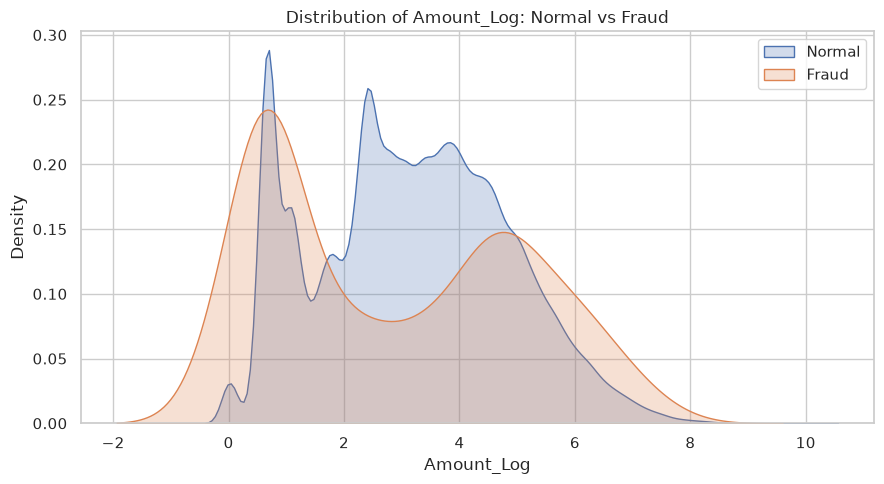

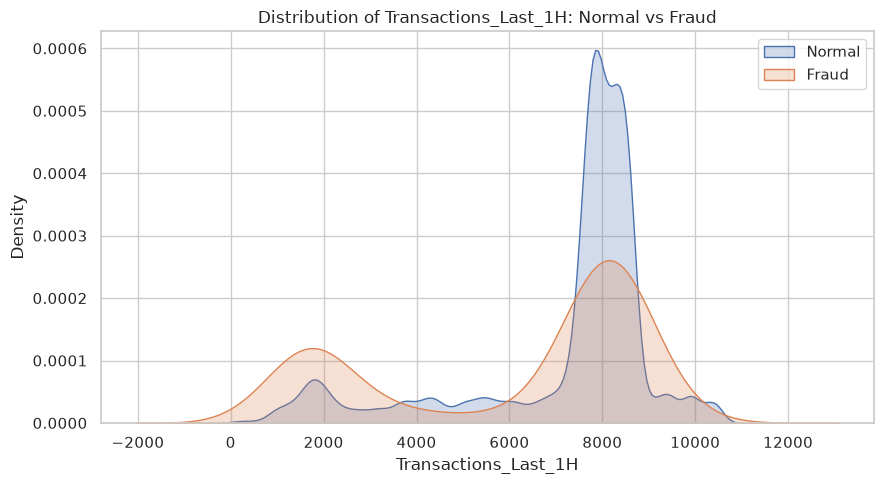

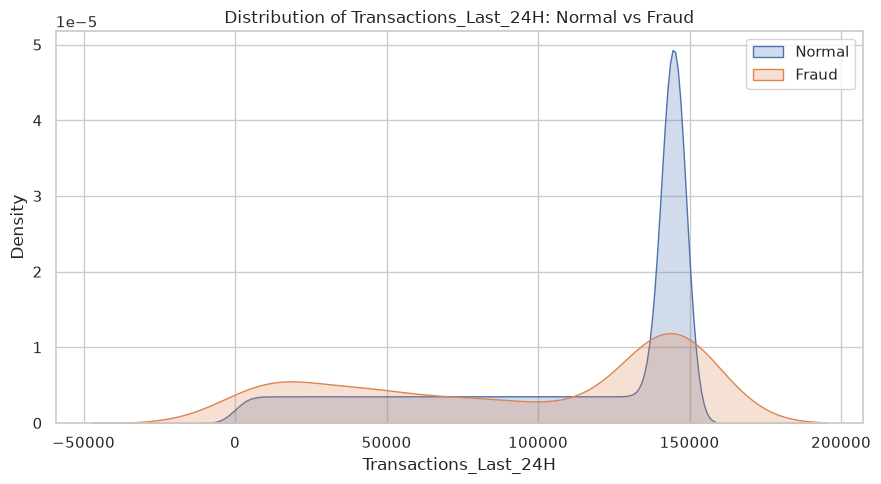

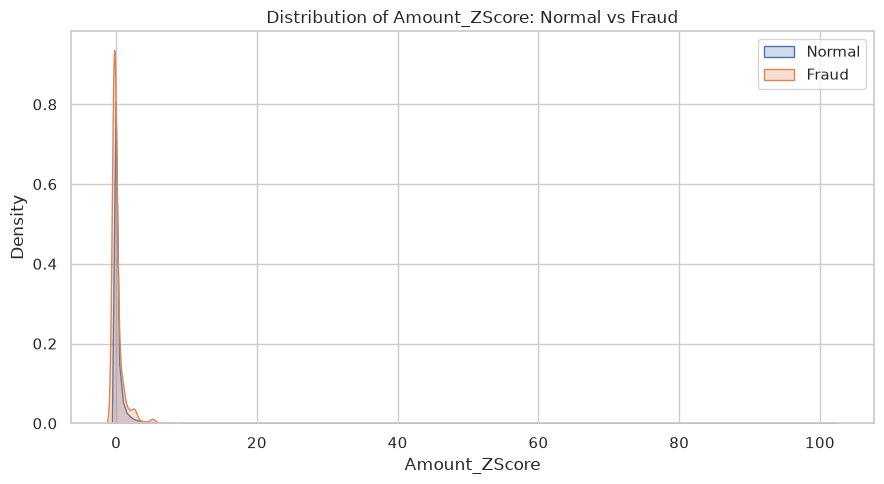

In [ ]:

# DISTRIBUTION COMPARISON


# Ensure we only use behavioral features that exist and are numeric
numerical_behavioral_features = [
    f for f in behavioral_features
    if (f in df.columns) and pd.api.types.is_numeric_dtype(df[f])
]

if not numerical_behavioral_features:
    print("No numerical behavioral features found. Using available numeric features instead.")
    numerical_behavioral_features = [f for f in numerical_features if f in df.columns]

print("Numerical behavioral features used:", numerical_behavioral_features)

for feature in numerical_behavioral_features:

    plt.figure(figsize=(9, 5))

    # Read values directly from df so this cell is safe to run
    normal_values = df.loc[df[TARGET] == 0, feature].dropna()
    fraud_values = df.loc[df[TARGET] == 1, feature].dropna()

    sns.kdeplot(
    "x=normal_values,",
    "label=\"Normal\",",
    "fill=True"
)

    sns.kdeplot(
    "x=fraud_values,",
    "label=\"Fraud\",",
    "fill=True"
)

    plt.title(
        f"Distribution of {feature}: "
        "Normal vs Fraud"
    )

    plt.xlabel(feature)
    plt.ylabel("Density")

    plt.legend()
    plt.tight_layout()

    filename = (
        feature.lower()
        .replace(" ", "_")
        + "_distribution.png"
    )

    plt.show()

##5. Mann–Whitney U Test

Credit-card transaction features can often be highly skewed, and the fraud sample consists of only 473 observations Therefore, instead of the independent t-test—which relies on the assumption of normality—we will use the Mann–Whitney U test here.

In [33]:

# MANN-WHITNEY U TEST

mw_results = []

for feature in numerical_features:

    normal_values = (
        df.loc[df[TARGET] == 0, feature]
        .dropna()
        .values
    )

    fraud_values = (
        df.loc[df[TARGET] == 1, feature]
        .dropna()
        .values
    )

    # Skip if either group is empty
    if len(normal_values) == 0 or len(fraud_values) == 0:
        continue

    statistic, p_value = mannwhitneyu(
        normal_values,
        fraud_values,
        alternative="two-sided"
    )

    mw_results.append({

        "Feature": feature,

        "U_Statistic": statistic,

        "P_Value": p_value
    })


mw_df = pd.DataFrame(
    mw_results
)

display(
    mw_df.sort_values("P_Value")
)

,Feature,U_Statistic,P_Value
14,V14,126896444.00000,0.00000
4,V4,8540423.00000,0.00000
12,V12,125197232.00000,0.00000
11,V11,11411882.00000,0.00000
10,V10,121998541.00000,0.00000
3,V3,121738405.00000,0.00000
2,V2,20123145.00000,0.00000
16,V16,112734405.00000,0.00000
9,V9,112714371.00000,0.00000
7,V7,111151906.00000,0.00000


In [34]:
#MULTIPLE TESTING CORRECTION

reject, adjusted_p_values, _, _ = (
    multipletests(
        mw_df["P_Value"],
        alpha=0.05,
        method="fdr_bh"
    )
)

mw_df["Adjusted_P_Value"] = (
    adjusted_p_values
)

mw_df["Significant"] = reject

mw_df = mw_df.sort_values(
    "Adjusted_P_Value"
)

display(mw_df)

,Feature,U_Statistic,P_Value,Adjusted_P_Value,Significant
14,V14,126896444.00000,0.00000,0.00000,True
4,V4,8540423.00000,0.00000,0.00000,True
12,V12,125197232.00000,0.00000,0.00000,True
11,V11,11411882.00000,0.00000,0.00000,True
10,V10,121998541.00000,0.00000,0.00000,True
3,V3,121738405.00000,0.00000,0.00000,True
2,V2,20123145.00000,0.00000,0.00000,True
16,V16,112734405.00000,0.00000,0.00000,True
9,V9,112714371.00000,0.00000,0.00000,True
7,V7,111151906.00000,0.00000,0.00000,True


##6. Effect Size — Cliff's Delta

The p-value alone is not sufficient here.This is because our dataset is very large; even very small differences can be statistically significant.Therefore, we will use Cliff's Delta.

In [ ]:
# CLIFF'S DELTA

def cliffs_delta(x, y):
    """
    Calculate Cliff's Delta.

    Parameters
    ----------
    x : array-like
        First group (fraud).

    y : array-like
        Second group (normal).

    Returns
    -------
    float
        Cliff's Delta.

    Interpretation
    --------------
    Positive value:
        Fraud group tends to have larger values.

    Negative value:
        Fraud group tends to have smaller values.

    Near zero:
        Little practical separation.
    """

    x = np.asarray(x)
    y = np.asarray(y)

    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]

    nx = len(x)
    ny = len(y)

    # Combine both groups and calculate ranks
    combined = np.concatenate(
        [x, y]
    )

    ranks = rankdata(
        combined
    )

    rank_x = ranks[:nx]

    # Mann-Whitney U statistic
    U = (
        rank_x.sum()
        - (nx * (nx + 1) / 2)
    )

    delta = (
        (2 * U) / (nx * ny)
    ) - 1

    return delta

In [38]:

# EFFECT SIZE

effect_results = []

for feature in numerical_features:

    # Skip features that are not present in the current dataframe
    if feature not in df.columns:
        continue

    # Read from the main dataframe to ensure engineered columns (e.g. Transaction_Hour)
    # are available even if normal_df / fraud_df were created earlier.
    normal_values = (
        df.loc[df[TARGET] == 0, feature]
        .dropna()
        .values
    )

    fraud_values = (
        df.loc[df[TARGET] == 1, feature]
        .dropna()
        .values
    )

    if len(normal_values) == 0:
        continue

    if len(fraud_values) == 0:
        continue

    delta = cliffs_delta(
        fraud_values,
        normal_values
    )

    effect_results.append({

        "Feature": feature,

        "Cliffs_Delta": delta,

        "Absolute_Cliffs_Delta": abs(delta)
    })


effect_df = pd.DataFrame(
    effect_results
)

display(
    effect_df.sort_values(
        "Absolute_Cliffs_Delta",
        ascending=False
    )
)

,Feature,Cliffs_Delta,Absolute_Cliffs_Delta
14,V14,-0.89428,0.89428
4,V4,0.87251,0.87251
12,V12,-0.86891,0.86891
11,V11,0.82965,0.82965
10,V10,-0.82116,0.82116
3,V3,-0.81728,0.81728
2,V2,0.69961,0.69961
16,V16,-0.68287,0.68287
9,V9,-0.68257,0.68257
7,V7,-0.65925,0.65925


In [39]:

# EFFECT SIZE INTERPRETATION

def interpret_cliffs_delta(delta):

    magnitude = abs(delta)

    if magnitude < 0.147:
        return "Negligible"

    elif magnitude < 0.33:
        return "Small"

    elif magnitude < 0.474:
        return "Medium"

    else:
        return "Large"


effect_df["Effect_Size"] = (
    effect_df["Cliffs_Delta"]
    .apply(interpret_cliffs_delta)
)

display(
    effect_df.sort_values(
        "Absolute_Cliffs_Delta",
        ascending=False
    )
)

,Feature,Cliffs_Delta,Absolute_Cliffs_Delta,Effect_Size
14,V14,-0.89428,0.89428,Large
4,V4,0.87251,0.87251,Large
12,V12,-0.86891,0.86891,Large
11,V11,0.82965,0.82965,Large
10,V10,-0.82116,0.82116,Large
3,V3,-0.81728,0.81728,Large
2,V2,0.69961,0.69961,Large
16,V16,-0.68287,0.68287,Large
9,V9,-0.68257,0.68257,Large
7,V7,-0.65925,0.65925,Large


## 7. Create Main Statistical Table

This table store : Feature,Normal_Mean, Normal_Median, 	Normal_Std, Normal_Q1, Normal_Q3, Fraud_Mean, Fraud_Median, Fraud_Std, Fraud_Q1, Fraud_Q3, Median_Difference, Median_Ratio, U_Statistic, P_Value, Adjusted_P_Value, Significant	Cliffs_Delta, Absolute_Cliffs_Delta	Effect_Size.

In [40]:
# ============================================================
# MAIN NUMERICAL STATISTICAL TABLE
# ============================================================

statistical_results = (
    descriptive_df
    .merge(
        mw_df,
        on="Feature",
        how="left"
    )
    .merge(
        effect_df,
        on="Feature",
        how="left"
    )
)

statistical_results = (
    statistical_results
    .sort_values(
        "Adjusted_P_Value"
    )
)

display(
    statistical_results
)

,Feature,Normal_Mean,Normal_Median,Normal_Std,Normal_Q1,Normal_Q3,Fraud_Mean,Fraud_Median,Fraud_Std,Fraud_Q1,Fraud_Q3,Median_Difference,Median_Ratio,U_Statistic,P_Value,Adjusted_P_Value,Significant,Cliffs_Delta,Absolute_Cliffs_Delta,Effect_Size
14,V14,0.01167,0.05149,0.89438,-0.42271,0.49306,-6.83595,-6.59055,4.25321,-9.50514,-4.25247,-6.64204,-128.00634,126896444.00000,0.00000,0.00000,True,-0.89428,0.89428,Large
4,V4,-0.01044,-0.02450,1.39857,-0.85160,0.73423,4.47259,4.10010,2.87152,2.28864,6.29092,4.12460,-167.35314,8540423.00000,0.00000,0.00000,True,0.87251,0.87251,Large
12,V12,0.00948,0.14057,0.94538,-0.40288,0.61778,-6.10325,-5.43735,4.58233,-8.60165,-2.82495,-5.57793,-38.68005,125197232.00000,0.00000,0.00000,True,-0.86891,0.86891,Large
11,V11,-0.00600,-0.03445,1.00226,-0.76274,0.73655,3.71635,3.52573,2.67282,1.92857,5.22412,3.56017,-102.35584,11411882.00000,0.00000,0.00000,True,0.82965,0.82965,Large
10,V10,0.00766,-0.09212,1.03632,-0.53315,0.45479,-5.45327,-4.46628,4.70645,-7.29780,-2.44747,-4.37416,48.48316,121998541.00000,0.00000,0.00000,True,-0.82116,0.82116,Large
3,V3,0.01285,0.18225,1.45759,-0.88397,1.02826,-6.72960,-4.87540,6.90965,-7.92651,-2.17145,-5.05764,-26.75154,121738405.00000,0.00000,0.00000,True,-0.81728,0.81728,Large
2,V2,-0.00983,0.06256,1.63352,-0.60140,0.79701,3.40596,2.61710,4.12250,1.14538,4.57174,2.55454,41.83276,20123145.00000,0.00000,0.00000,True,0.69961,0.69961,Large
16,V16,0.00785,0.06810,0.84461,-0.46424,0.52397,-4.00096,-3.30290,3.83172,-6.46919,-1.14247,-3.37100,-48.50090,112734405.00000,0.00000,0.00000,True,-0.68287,0.68287,Large
9,V9,0.00261,-0.05137,1.08690,-0.64165,0.59697,-2.52212,-2.09905,2.46505,-3.79676,-0.78839,-2.04768,40.86278,112714371.00000,0.00000,0.00000,True,-0.68257,0.68257,Large
7,V7,0.01045,0.04166,1.17748,-0.55015,0.57103,-5.17591,-2.90208,6.85802,-6.98919,-0.90719,-2.94374,-69.65465,111151906.00000,0.00000,0.00000,True,-0.65925,0.65925,Large


##8. Statistical Feature Ranking


In [41]:

# SIGNIFICANT FEATURES

significant_features = (
    statistical_results[
        statistical_results[
            "Significant"
        ] == True
    ]
    .sort_values(
        "Absolute_Cliffs_Delta",
        ascending=False
    )
)

print(
    "Number of statistically significant features:",
    len(significant_features)
)

display(
    significant_features[
        [
            "Feature",
            "Normal_Median",
            "Fraud_Median",
            "Adjusted_P_Value",
            "Cliffs_Delta",
            "Effect_Size"
        ]
    ]
)

Number of statistically significant features: 34


,Feature,Normal_Median,Fraud_Median,Adjusted_P_Value,Cliffs_Delta,Effect_Size
14,V14,0.05149,-6.59055,0.00000,-0.89428,Large
4,V4,-0.02450,4.10010,0.00000,0.87251,Large
12,V12,0.14057,-5.43735,0.00000,-0.86891,Large
11,V11,-0.03445,3.52573,0.00000,0.82965,Large
10,V10,-0.09212,-4.46628,0.00000,-0.82116,Large
3,V3,0.18225,-4.87540,0.00000,-0.81728,Large
2,V2,0.06256,2.61710,0.00000,0.69961,Large
16,V16,0.06810,-3.30290,0.00000,-0.68287,Large
9,V9,-0.05137,-2.09905,0.00000,-0.68257,Large
7,V7,0.04166,-2.90208,0.00000,-0.65925,Large


In [42]:

# PRACTICALLY MEANINGFUL FEATURES

meaningful_features = (
    statistical_results[
        statistical_results[
            "Effect_Size"
        ].isin(
            [
                "Small",
                "Medium",
                "Large"
            ]
        )
    ]
    .sort_values(
        "Absolute_Cliffs_Delta",
        ascending=False
    )
)

print(
    "Features with at least a small effect size:"
)

display(
    meaningful_features[
        [
            "Feature",
            "Adjusted_P_Value",
            "Cliffs_Delta",
            "Effect_Size"
        ]
    ]
)

Features with at least a small effect size:


,Feature,Adjusted_P_Value,Cliffs_Delta,Effect_Size
14,V14,0.00000,-0.89428,Large
4,V4,0.00000,0.87251,Large
12,V12,0.00000,-0.86891,Large
11,V11,0.00000,0.82965,Large
10,V10,0.00000,-0.82116,Large
3,V3,0.00000,-0.81728,Large
2,V2,0.00000,0.69961,Large
16,V16,0.00000,-0.68287,Large
9,V9,0.00000,-0.68257,Large
7,V7,0.00000,-0.65925,Large


##9. Top Statistical Features Visualization

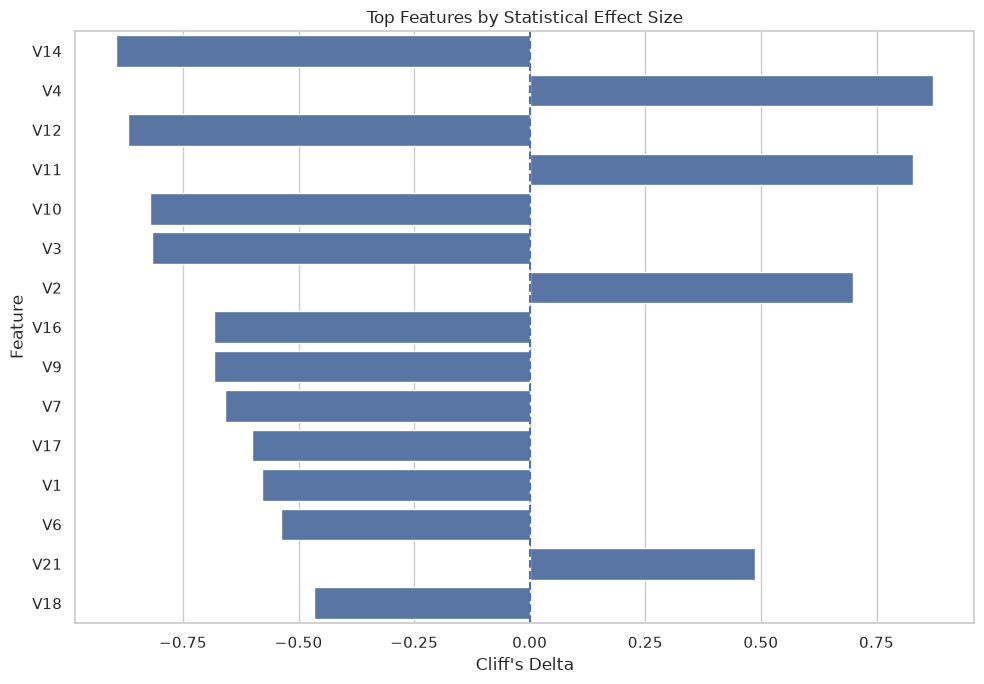

In [43]:

# TOP FEATURES BY EFFECT SIZE

top_effect_features = (
    statistical_results
    .sort_values(
        "Absolute_Cliffs_Delta",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_effect_features,
    x="Cliffs_Delta",
    y="Feature"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Top Features by Statistical Effect Size"
)

plt.xlabel("Cliff's Delta")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/top_statistical_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##10.Distribution Analysis for Top Features

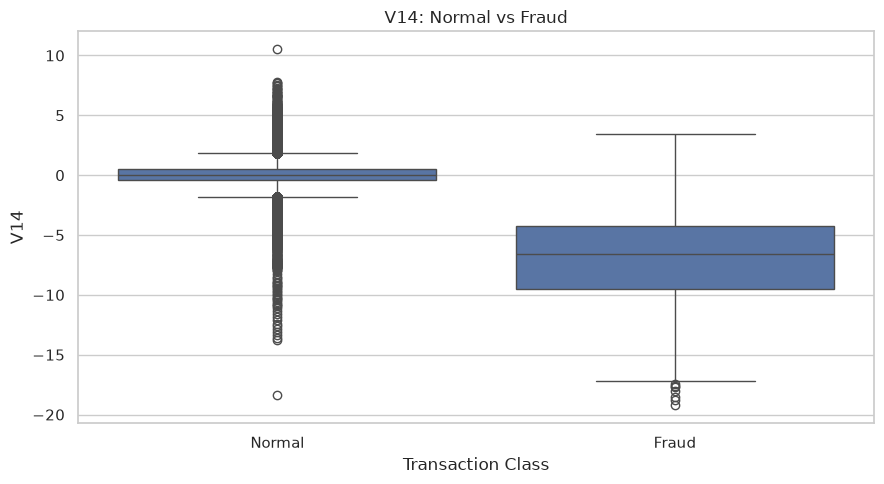

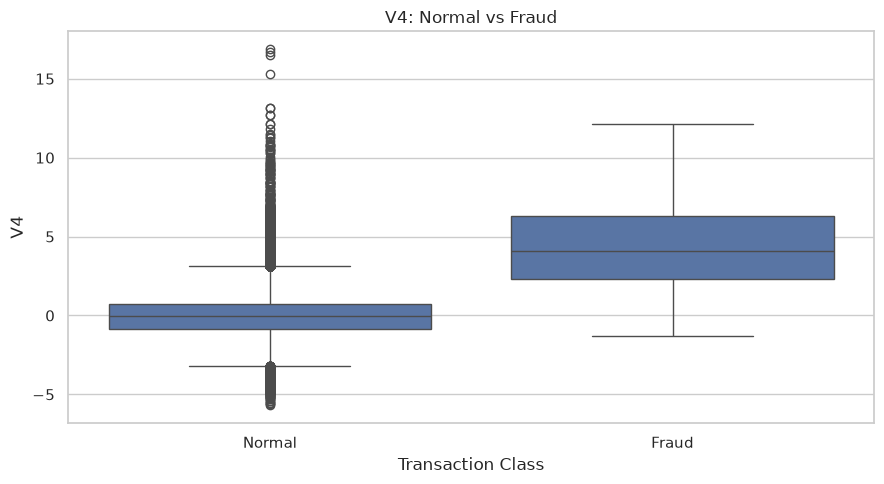

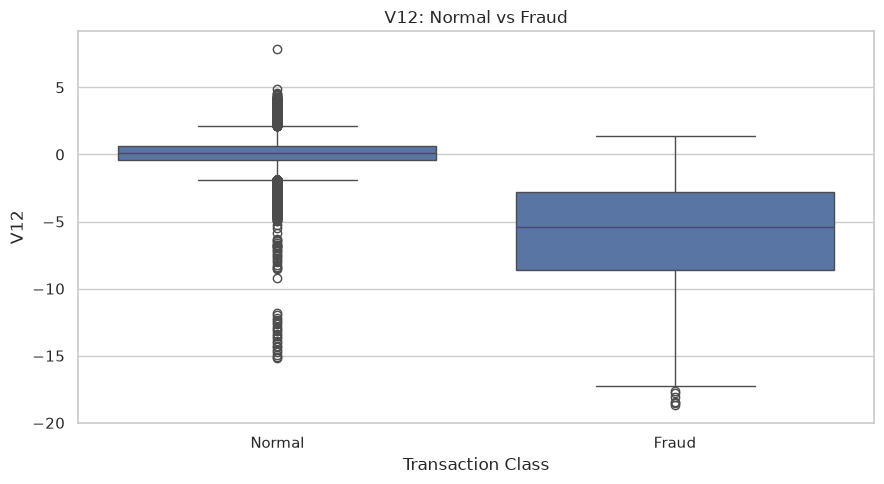

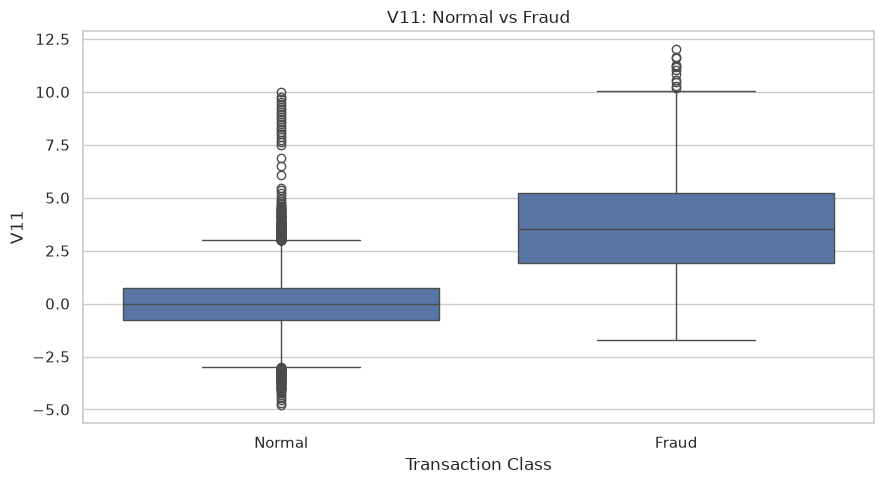

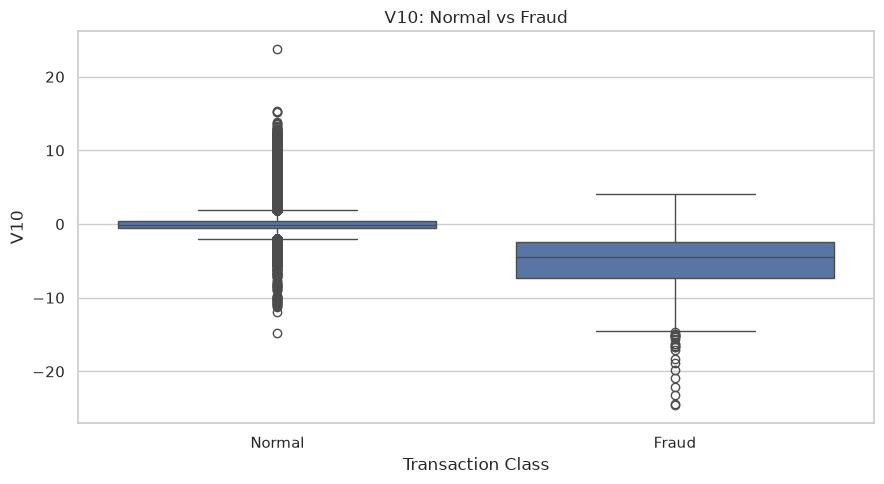

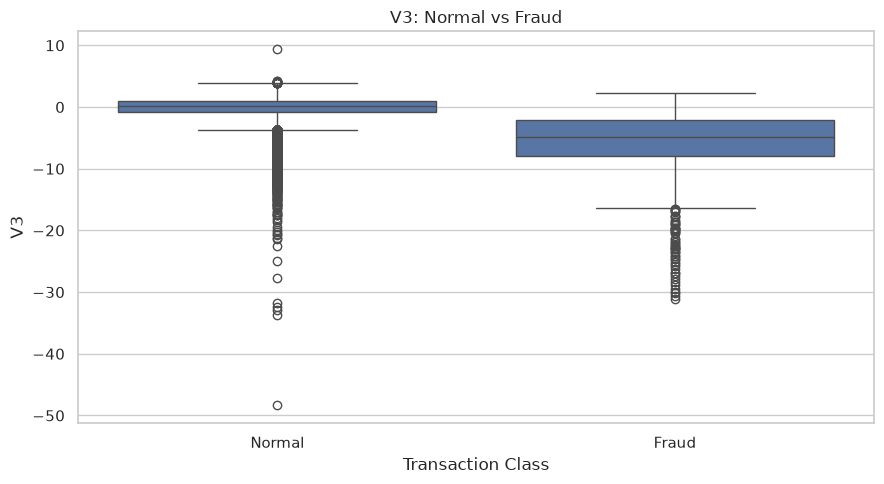

In [44]:

# TOP FEATURE DISTRIBUTIONS

top_features = (
    top_effect_features[
        "Feature"
    ]
    .head(6)
    .tolist()
)

for feature in top_features:

    plt.figure(figsize=(9, 5))

    sns.boxplot(
        data=df,
        x="Class",
        y=feature
    )

    plt.xticks(
        [0, 1],
        ["Normal", "Fraud"]
    )

    plt.title(
        f"{feature}: Normal vs Fraud"
    )

    plt.xlabel("Transaction Class")
    plt.ylabel(feature)

    plt.tight_layout()

    filename = (
        feature
        .lower()
        .replace(" ", "_")
        + "_boxplot.png"
    )

    plt.savefig(
        f"{FIGURE_DIR}/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [ ]:

# AMOUNT CATEGORY ANALYSIS

if "Amount_Category" in df.columns:

    amount_category_table = (
        df.groupby(
            "Amount_Category",
            observed=True
        )
        .agg(
            Total_Transactions=(
                "Class",
                "count"
            ),

            Fraud_Transactions=(
                "Class",
                "sum"
            )
        )
        .reset_index()
    )

    amount_category_table[
        "Fraud_Rate"
    ] = (
        amount_category_table[
            "Fraud_Transactions"
        ]
        /
        amount_category_table[
            "Total_Transactions"
        ]
    )

    amount_category_table[
        "Fraud_Rate_Percent"
    ] = (
        amount_category_table[
            "Fraud_Rate"
        ] * 100
    )

    display(
        amount_category_table.round(4)
    )

,Amount_Category,Total_Transactions,Fraud_Transactions,Fraud_Rate,Fraud_Rate_Percent
0,High,19661,48,0.00240,0.24410
1,Low,188340,268,0.00140,0.14230
2,Medium,64808,98,0.00150,0.15120
3,Very High,9109,34,0.00370,0.37330
4,Zero,1808,25,0.01380,1.38270


##11.Amount Category — Chi-Square Test

H₀ = Amount_Category and fraud status independent.
H₁= Amount_Category and fraud status associated.

In [46]:

# CHI-SQUARE TEST

if "Amount_Category" in df.columns:

    amount_contingency = pd.crosstab(
        df["Amount_Category"],
        df["Class"]
    )

    print("Contingency table:")
    display(
        amount_contingency
    )

    chi2_amount, p_amount, dof_amount, expected_amount = (
        chi2_contingency(
            amount_contingency
        )
    )

    print(
        f"Chi-square statistic : {chi2_amount:.5f}"
    )

    print(
        f"Degrees of freedom   : {dof_amount}"
    )

    print(
        f"P-value              : {p_amount:.10e}"
    )

Contingency table:


Class,0,1
Amount_Category,,
High,19613,48
Low,188072,268
Medium,64710,98
Very High,9075,34
Zero,1783,25


Chi-square statistic : 198.75066
Degrees of freedom   : 4
P-value              : 6.9738173190e-42


In [47]:

# CRAMER'S V

def cramers_v(table):

    chi2, _, _, _ = (
        chi2_contingency(table)
    )

    n = table.to_numpy().sum()

    rows, columns = table.shape

    phi2 = chi2 / n

    phi2_corrected = max(
        0,
        phi2
        - (
            (columns - 1)
            * (rows - 1)
        )
        / (n - 1)
    )

    rows_corrected = (
        rows
        - ((rows - 1) ** 2)
        / (n - 1)
    )

    columns_corrected = (
        columns
        - ((columns - 1) ** 2)
        / (n - 1)
    )

    denominator = min(
        columns_corrected - 1,
        rows_corrected - 1
    )

    return np.sqrt(
        phi2_corrected / denominator
    )


if "Amount_Category" in df.columns:

    amount_cramers_v = cramers_v(
        amount_contingency
    )

    print(
        f"Cramér's V: "
        f"{amount_cramers_v:.5f}"
    )

Cramér's V: 0.02620


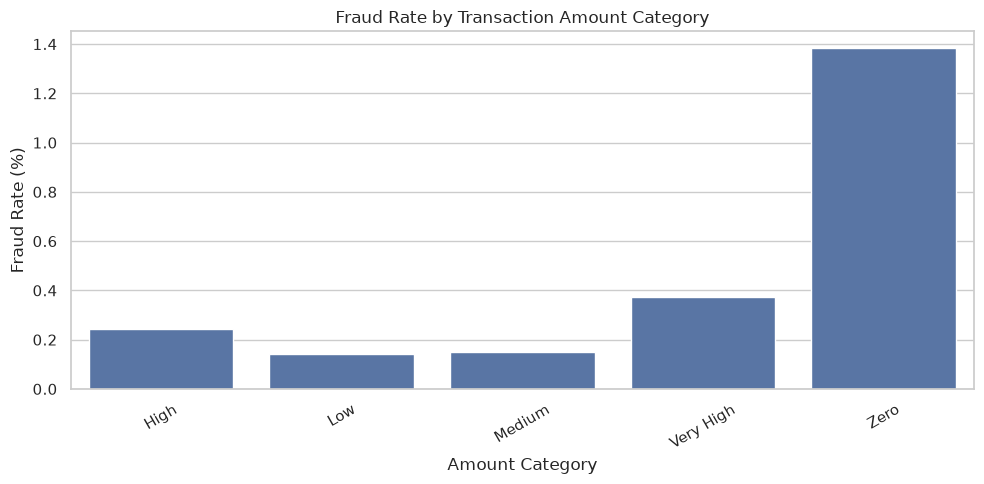

In [49]:

# Visualize FRAUD RATE BY AMOUNT CATEGORY

if "Amount_Category" in df.columns:

    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=amount_category_table,
        x="Amount_Category",
        y="Fraud_Rate_Percent"
    )

    plt.title(
        "Fraud Rate by Transaction Amount Category"
    )

    plt.xlabel("Amount Category")
    plt.ylabel("Fraud Rate (%)")

    plt.xticks(
        rotation=30
    )

    plt.tight_layout()

    plt.savefig(
        f"{FIGURE_DIR}/amount_category_fraud_rate.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

##12. Transaction Frequency Analysis

Two important behaviornal features : Transactions_Last_1H and Transactions_Last_24H

In [51]:

# TRANSACTION FREQUENCY SUMMARY

frequency_features = [
    feature
    for feature in [
        "Transactions_Last_1H",
        "Transactions_Last_24H"
    ]
    if feature in df.columns
]

frequency_results = []

for feature in frequency_features:

    normal_values = (
        normal_df[feature]
        .dropna()
    )

    fraud_values = (
        fraud_df[feature]
        .dropna()
    )

    frequency_results.append({

        "Feature": feature,

        "Normal_Median": normal_values.median(),
        "Fraud_Median": fraud_values.median(),

        "Normal_Mean": normal_values.mean(),
        "Fraud_Mean": fraud_values.mean(),

        "Normal_95th": normal_values.quantile(
            0.95
        ),

        "Fraud_95th": fraud_values.quantile(
            0.95
        )
    })

frequency_df = pd.DataFrame(
    frequency_results
)

display(
    frequency_df.round(4)
)

,Feature,Normal_Median,Fraud_Median,Normal_Mean,Fraud_Mean,Normal_95th,Fraud_95th
0,Transactions_Last_1H,7904.00000,7774.00000,7218.66230,6099.86050,9337.00000,8678.20000
1,Transactions_Last_24H,139787.00000,113816.00000,107858.55400,93391.98730,146807.00000,146854.80000


In [52]:

# FREQUENCY VS FRAUD RATE

for feature in frequency_features:

    # Quantile bins
    bin_column = (
        f"{feature}_Bin"
    )

    df[bin_column] = pd.qcut(
        df[feature],
        q=5,
        duplicates="drop"
    )

    frequency_analysis = (
        df.groupby(
            bin_column,
            observed=True
        )
        .agg(
            Transactions=(
                "Class",
                "count"
            ),

            Fraud_Count=(
                "Class",
                "sum"
            )
        )
        .reset_index()
    )

    frequency_analysis[
        "Fraud_Rate_Percent"
    ] = (
        frequency_analysis[
            "Fraud_Count"
        ]
        /
        frequency_analysis[
            "Transactions"
        ]
        * 100
    )

    print(
        f"\n{feature}"
    )

    display(
        frequency_analysis.round(4)
    )


Transactions_Last_1H


,Transactions_Last_1H_Bin,Transactions,Fraud_Count,Fraud_Rate_Percent
0,"(-0.001, 6339.0]",56755,163,0.28720
1,"(6339.0, 7775.0]",56883,74,0.13010
2,"(7775.0, 8102.0]",56832,60,0.10560
3,"(8102.0, 8466.0]",56561,104,0.18390
4,"(8466.0, 10526.0]",56695,72,0.12700



Transactions_Last_24H


,Transactions_Last_24H_Bin,Transactions,Fraud_Count,Fraud_Rate_Percent
0,"(-0.001, 56743.0]",56747,157,0.27670
1,"(56743.0, 113489.0]",56744,79,0.13920
2,"(113489.0, 144080.0]",56765,108,0.19030
3,"(144080.0, 144624.0]",56755,43,0.07580
4,"(144624.0, 147535.0]",56715,86,0.15160
